In [1]:
# Bengio et al. 2003 MLP language model paper 
# https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf

In [2]:
words = open("/kaggle/input/datasets/anirudhtn/commonnames/Names from Makemore.txt").read().splitlines()
words[:5]
len(words)

32033

In [3]:
import torch
import math
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

In [4]:
# create character <-> number lookups
chars = sorted(set("".join(words)))
chars
stoi = {c: i + 1 for i, c in enumerate(chars)}
itos = {i + 1: c for i, c in enumerate(chars)}

stoi['.'] = 0; itos[0] = '.'
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [5]:
# building the dataset 
# with a 4 character input(block), we try to predict the 5th character

block_size = 4

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        # print(w + '.')

        for ch in (w + '.'):
            # print(ch)
            ix = stoi[ch]
            # print(context)
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

X, Y = build_dataset(words[:6])
X.shape


torch.Size([42, 4])

In [6]:
# 75% training, 15% dev, 10% test

sz = len(words)
n1 = int(0.75 * sz)
n2 = int(0.90 * sz)


random.seed(42)
random.shuffle(words)

X_training, Y_training = build_dataset(words[:n1])
X_dev, Y_dev = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

X_training.shape, X_dev.shape, X_test.shape

(torch.Size([171195, 4]), torch.Size([34085, 4]), torch.Size([22866, 4]))

In [7]:
device = 'cuda'

g = torch.Generator().manual_seed(2147483647) # for reproducibility

# create an embedded vector for each character - use 5 dimensional embeddings

C = torch.randn(27, 10, generator=g)

# we have the input X, embedding C, output Y
# we need weights W1 for the embeddings and W2 for the hidden layer

# C is 27x10 and assume we want to give 100 inputs to the hidden layer - so W1 should be 10x100
# actually no, we are feeding inputs from 4 candidates to each neuron - each of which should be differentiable - 
# so, we set 10x4 and 100, 40x100
W1 = torch.randn(40, 100, generator=g)

# bias - one per neuron
b1 = torch.randn(100, generator=g)

# C @ W1 will be the output of the embedding layer into the hidden layer. 
# Now, hidden layer is going to output tanh suppressed values to a softmax layer.

# Hidden layer will have 27 neurons - one for each character. So, we have a 50x27
W2 = torch.randn(100, 27, generator=g)
b2 = torch.randn(27, generator=g)

parameters = [W1, W2, b1, b2, C]

In [8]:
# total parameters
for param in parameters: param.requires_grad = True

total_params = sum(p.nelement() for p in parameters)
total_params


7097

In [9]:
# now, we train!

loss_i, i = [], []

for _ in range(100000):

    ##### create minibatches ####

    batch = torch.randint(0, X_training.shape[0], (48,))
    
    #######   Forward pass   #######
    embedding = C[X_training[batch]]
    
    # output of the first embedded layer
    h = torch.tanh(embedding.view(-1, 40) @ W1 + b1) # broadcasting should support this addition
    
    h.shape
    
    # first and only hidden layer
    
    logits = h @ W2 + b2
    logits.shape
    
    # calculating loss with negative log likelihood 
    loss = F.cross_entropy(logits, Y_training[batch])  

    l2_loss = (C**2).sum() + (W1**2).sum() + (W2**2).sum()
    weight_decay = 0.0001

    loss += weight_decay*l2_loss

    i.append(_)
    loss_i.append(loss.item())
    
    #######   Backward pass   #######
    
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    
    ###### update weights #######
    learning_rate = 0.5 if _ < 2000 else 0.1 if _ < 20000 else 0.01
    for p in parameters:
        p.data += -learning_rate * p.grad

print(loss)


tensor(1.9973, grad_fn=<AddBackward0>)


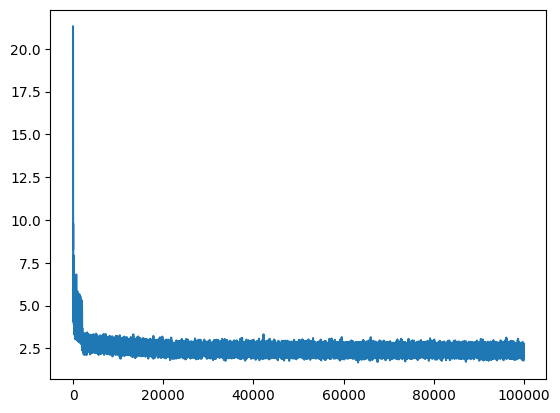

In [10]:
plt.plot(i, loss_i)

In [11]:
# dev set testing

embedding = C[X_dev]
h = torch.tanh(embedding.view(-1, 40) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Y_dev)
l2_loss = (C**2).sum() + (W1**2).sum() + (W2**2).sum()
weight_decay = 0.0001

loss += weight_decay*l2_loss
loss

tensor(2.3596, grad_fn=<AddBackward0>)

In [12]:
# testing set

embedding = C[X_test]
h = torch.tanh(embedding.view(-1, 40) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits, Y_test)
l2_loss = (C**2).sum() + (W1**2).sum() + (W2**2).sum()
weight_decay = 0.0001

loss += weight_decay*l2_loss
loss

tensor(2.3595, grad_fn=<AddBackward0>)

In [13]:
# inference
g = torch.Generator().manual_seed(2147483647+15)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      # print(C.shape)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

amnyah.
kabre.
ahekan.
syted.
alaxber.
mehan.
kyas.
eteb.
dioladamar.
halieiey.
laydmennccetelmon.
din.
mareele.
mauviraceey.
aashone.
ansa.
euna.
merbyn.
amikrivina.
edby.
